In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

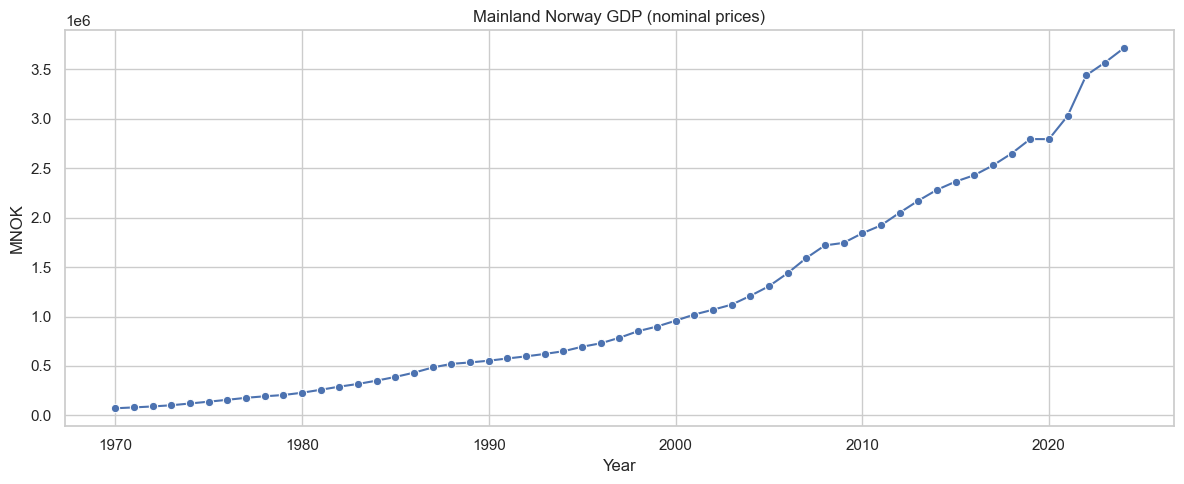

In [16]:
gdp = pd.read_csv('data/09189_20260206-101414.csv', delimiter=';')
gdp['gdp'] = gdp['gpd_ex_gov'] + gdp['gdp_gov']

x = 'year'
y = 'gdp'
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.lineplot(data=gdp.sort_values(x), x=x, y=y, marker="o")
plt.title("Mainland Norway GDP (nominal prices)")
plt.xlabel("Year")
plt.ylabel("MNOK")
plt.tight_layout()
plt.show()

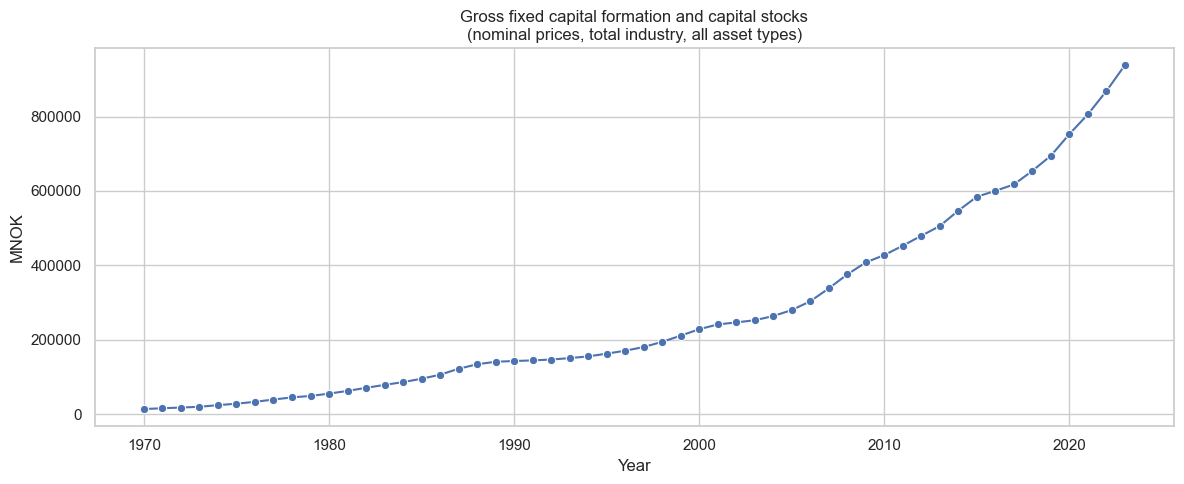

In [17]:
gdp = pd.read_csv('data/11189_20260206-101742.csv', delimiter=';')

x = 'year'
y = 'prices'
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.lineplot(data=gdp.sort_values(x), x=x, y=y, marker="o")
plt.title("Gross fixed capital formation and capital stocks\n(nominal prices, total industry, all asset types)")
plt.xlabel("Year")
plt.ylabel("MNOK")
plt.tight_layout()
plt.show()

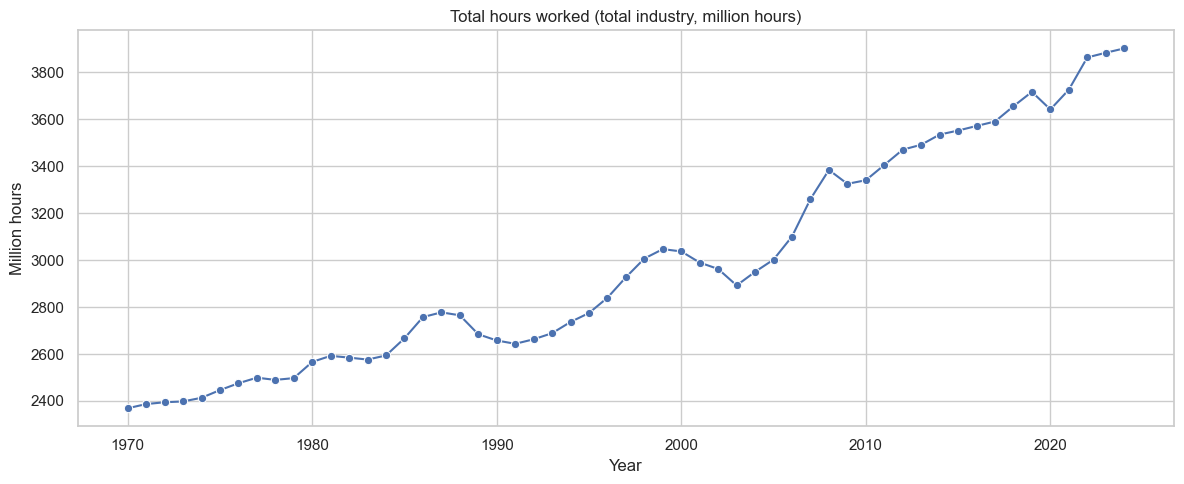

In [12]:
gdp = pd.read_csv('data/09174_20260206-100052.csv', delimiter=';')

x = 'year'
y = 'million workhours (total)'
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
sns.lineplot(data=gdp.sort_values(x), x=x, y=y, marker="o")
plt.title("Total hours worked (total industry, million hours)")
plt.xlabel("Year")
plt.ylabel("Million hours")
plt.tight_layout()
plt.show()

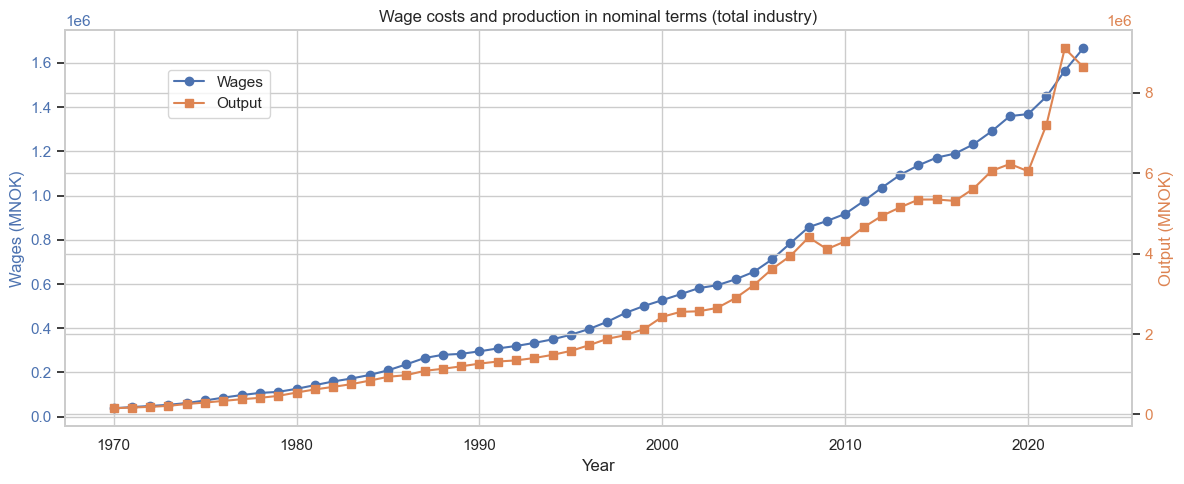

In [48]:
wages = pd.read_csv('data/wages.csv', delimiter=';')
wages = wages.T 
wages = wages.reset_index()
wages.columns = ["year", "Total industry"]
wages = wages[wages["year"].ne("year")].reset_index(drop=True)
wages["year"] = wages["year"].astype(int)

output = pd.read_csv('data/09170_20260206-103416.csv', delimiter=';')
output = output.rename(columns={"Output (MNOK)": "output"})
output["year"] = output["year"].astype(int)

merged = wages.merge(output, on="year").sort_values("year")

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(merged["year"], merged["Total industry"], marker="o", label="Wages", color="C0")
ax1.set_ylabel("Wages (MNOK)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

ax2 = ax1.twinx()
ax2.plot(merged["year"], merged["output"], marker="s", label="Output", color="C1")
ax2.set_ylabel("Output (MNOK)", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

ax1.set_xlabel("Year")
plt.title("Wage costs and production in nominal terms (total industry)")
fig.legend(loc="upper left", bbox_to_anchor=(0.14, 0.86))
plt.tight_layout()
plt.show()